In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# Pyramid Chart

In [2]:
df = pd.read_excel('data/revenue_ger_veg.xlsx', sheet_name='Data', skiprows=4, usecols='B:C')
df.columns = ['Category', '2019']

In [3]:
df

,Category,2019
0,Discounter,365
1,Small convenience stores,347
2,Large convenience stores,295
3,Large supermarkets,129
4,Drugstores,67
5,Small supermarkets,14


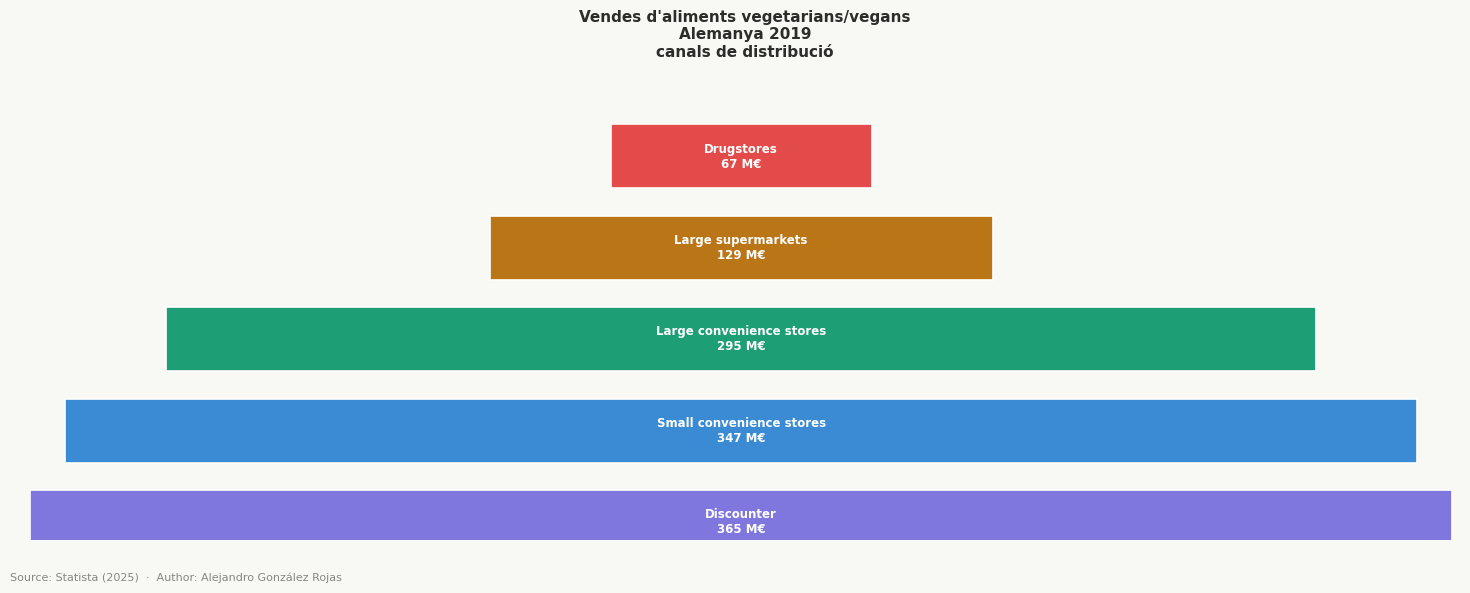

In [4]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
})

fig, ax1 = plt.subplots(figsize=(15, 6))
fig.patch.set_facecolor("#F8F8F5")

ax1.set_facecolor("#F8F8F5")

nivells = df['Category'].to_list()
valors  = df['2019'].to_list()
colors  = ["#7F77DD", "#3B8BD4", "#1D9E75", "#BA7517", "#E24B4A"]

max_val = max(valors)
bar_height = 0.7

for i, (nom, val, color) in enumerate(zip(nivells, valors, colors)):
    y = i
    left = (max_val - val) / 2
    bar = ax1.barh(y,val, left=left, height=bar_height, color=color,edgecolor="white", linewidth=1.2)
    
    ax1.text(left+val/2, y, nom + f"\n{val} M€", ha="center", va="center", fontsize=8.5, color="white", fontweight="bold")

ax1.set_xlim(0, max_val + 2)
ax1.set_ylim(-0.2,len(nivells) - 1)
ax1.axis("off")
ax1.set_title("Vendes d'aliments vegetarians/vegans\nAlemanya 2019\ncanals de distribució", fontsize=11,
              fontweight="bold", color="#2C2C2A")

fig.text(0.01, -0.01, "Source: Statista (2025)  ·  Author: Alejandro González Rojas",
         fontsize=8, color="#888780")

plt.tight_layout(pad=2.5)

## Gràfic de Piràmide — Distribució de Canals de Venda al Detall (2019)

**Font de dades:**

Statista — Ingressos per vendes d'aliments vegetarians i vegans a Alemanya el 2019, per canals de distribució de mercat
https://www.statista.com/statistics/1271448/vegetarian-vegan-food-sales-revenue-by-distribution-germany/


### Nom

Pyramid Chart (Gràfic de Piràmide o Gràfic Triangular). En funció del context també es coneix com a gràfic d'embut invertit quan les categories representen nivells jeràrquics d'una estructura.


### Origen i autoria

Els grafics de piràmide deriven dels primers diagrames estadístics del segle XIX. La variant demogràfica es va popularitzar als anys 1870–1880 de la mà d'estadístics europeus com Francis Amasa Walker, que la va emprar per representar la distribució de la població per edat i sexe. La piràmide com a metàfora de jerarquia va consolidar-se al segle XX, especialment a partir d'Abraham Maslow (1943), tot i que la forma visual triangular va ser afegida posteriorment per altres autors. No existeix un inventor únic de la variant proporcional usada en màrqueting i anàlisi de mercat.

### Avantatges i inconvenients

**Avantatges**
- Visualitza jerarquies i proporcions de manera molt intuïtiva i d'un sol cop d'ull
- Fa evident quins segments dominen (base) i quins són residuals (cim)
- Fàcil d'interpretar per a audiències no tècniques

**Inconvenients**
- L'àrea visual de cada segment no és estrictament proporcional al valor real, pot distorsionar la percepció de magnituds
- No és adequada per mostrar l'evolució temporal
- Amb molts segments (>7) la llegibilitat es redueix

### Tipus de dades admeses

- Dades categòriques ordenades amb valors numèrics associats, han de tenir una ordenació lògica
- No és adequada per a dades nominals sense ordre inherent ni per a sèries temporals.

### Exemples i aplicacions habituals

- Distribució de canals de venda: visualitzar quins formats comercials concentren més quota de mercat
- Piràmide de població: distribució per grups d'edat i sexe d'un país o regió
- Embuts de màrqueting i vendes: impressions → clics → leads → conversions → compres
- Distribució de riquesa: proporció de riquesa acumulada per percentil de població


### Lectura del gràfic

- La base (discounters i botigues de conveniència petites) concentra la major quota de mercat, reflectint el pes dels formats orientats al preu i la proximitat.
- Els formats intermedis (botigues de conveniència grans i supermercats grans) representen una quota significativa però clarament inferior.
- Les drogueries i supermercats petits formen l'estrat superior estret, canals de penetració molt limitada l'any 2019.

# Box Plot

In [5]:
df = pd.read_excel('data/consumer_confidence.xlsx', sheet_name='Data', skiprows=5, usecols='B:C')
df.columns = ['Country', 'Confidence (%)']

In [6]:
development = {
    "United States": "advanced", "Canada": "advanced", "Australia": "advanced",
    "Japan": "advanced", "South Korea": "advanced", "Germany": "advanced",
    "France": "advanced", "Great Britain": "advanced", "Italy": "advanced",
    "Spain": "advanced", "Netherlands": "advanced", "Belgium": "advanced",
    "Sweden": "advanced", "Ireland": "advanced", "Israel": "advanced",
    "India": "emerging", "Singapore": "emerging", "Malaysia": "emerging",
    "Indonesia": "emerging", "Thailand": "emerging", "Brazil": "emerging",
    "Mexico": "emerging", "Colombia": "emerging", "Peru": "emerging",
    "Chile": "emerging", "Argentina": "emerging", "South Africa": "emerging",
    "Poland": "emerging", "Hungary": "emerging", "Türkiye": "emerging"
}

In [7]:
df['development_level'] = df['Country'].map(development)

In [8]:
df

,Country,Confidence (%),development_level
0,India,57.0,emerging
1,Singapore,54.4,emerging
2,Sweden,54.4,advanced
3,Malaysia,54.1,emerging
4,Australia,53.9,advanced
5,Netherlands,52.8,advanced
6,Mexico,52.7,emerging
7,United States,52.4,advanced
8,Indonesia,52.3,emerging
9,Brazil,51.7,emerging


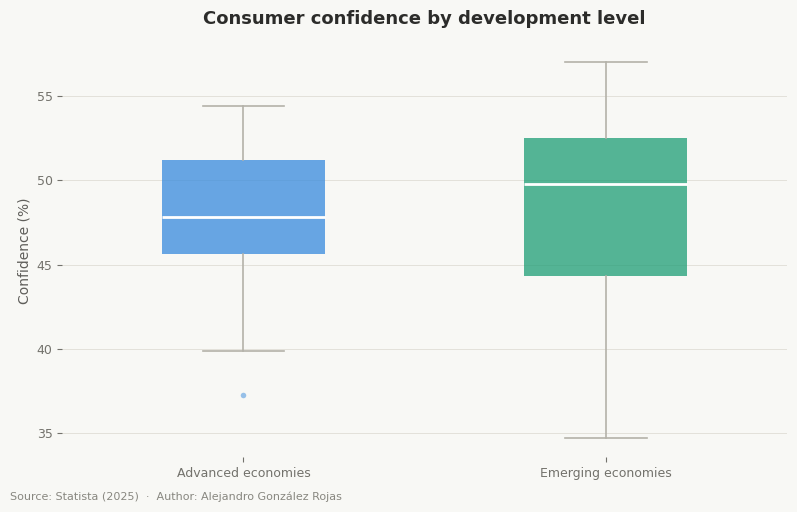

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#F8F8F5")
ax.set_facecolor("#F8F8F5")

colors = {"advanced": "#378ADD", "emerging": "#1D9E75"}
groups = [df[df["development_level"] == g]["Confidence (%)"] for g in colors]

bp = ax.boxplot(groups,
                patch_artist=True,
                widths=0.45,
                medianprops=dict(color="white", linewidth=2),
                boxprops=dict(linewidth=0),
                whiskerprops=dict(color="#B4B2A9", linewidth=1.2),
                capprops=dict(color="#B4B2A9", linewidth=1.2),
                flierprops=dict(marker="o", markersize=4, markeredgewidth=0, alpha=0.5))

for patch, color in zip(bp["boxes"], colors.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

for flier, color in zip(bp["fliers"], colors.values()): flier.set_markerfacecolor(color)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Advanced economies", "Emerging economies"], fontsize=11, color="#3d3d3a")
ax.set_ylabel("Confidence (%)", fontsize=10, color="#5F5E5A")
ax.set_title("Consumer confidence by development level", fontsize=13, fontweight="bold", color="#2C2C2A", pad=14)

ax.yaxis.grid(True, color="#E0DDD5", linewidth=0.6, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="both", colors="#73726c", labelsize=9)

fig.text(0.01, -0.01, "Source: Statista (2025)  ·  Author: Alejandro González Rojas",fontsize=8, color="#888780")

plt.tight_layout()
plt.show()

## Box Plot — Confiança del Consumidor per Nivell de Desenvolupament (2025)

**Font de dades:** 

Statista — Consumer confidence index in developed and emerging countries, 2025
https://www.statista.com/statistics/1034070/consumer-confidence-developed-emerging-countries/


### Nom

**Box Plot** (Diagrama de Caixa i Bigotis). Tambe es conegut com a box-and-whisker plot o gràfic de capsa, es un diagrama estadístic que resumeix la distribució d'un conjunt de dades numeriques mitjançant cinc estadistics clau: mínim, primer quartil (Q1), mediana (Q2), tercer quartil (Q3) i màxim, tot destacant els valors atipics.


### Origen i autoria

El box plot va ser inventat per l'estadistic John W. Tukey l'any 1969 i publicat formalment al seu llibre Exploratory Data Analysis (1977). Va néixer de la necessitat de visualitzar distribucions de dades de manera compacta i robusta, sense assumir cap distribució estadística previa. Tukey es tambe l'inventor del terme bit en informàtica i d'algorismes clau com la FFT (Fast Fourier Transform). Des de la seva publicació, el box plot s'ha convertit en un dels gràfics exploratoris més usats en estadística, ciencia de dades i recerca científica.


### Avantatges i inconvenients

**Avantatges**
- Mostra cinc estadístics clau simultàniament (mínim, Q1, mediana, Q3, màxim) en un element visual compacte
- Detecta i visualitza outliers de manera automàtica i explícita
- Ideal per comparar distribucions entre dos o més grups en el mateix eix
- Robust davant de mostres de mides diferents i no assumeix normalitat de les dades
- Permet identificar asimetries, dispersió i concentració de les dades d'un sol cop d'ull

**Inconvenients**
- No mostra la forma real de la distribució
- Menys intuïtiu per a audiències no tècniques
- Poc adequat per a mostres molt petites


### Tipus de dades admeses

- Dades numèriques contínues o discretes amb un rang de variació significatiu
- Adequat per a qualsevol variable que tingui una distribució comparable entre grups
- No es adequat per a dades categòriques ni variables binàries

### Exemples i aplicacions habituals

- Index de confiança del consumidor per grup de països (com en aquest dataset): comparar la distribució i dispersió de la confiança entre economies avançades i emergents
- Distribució de salaris per sector o departament: detectar diferències de mediana i outliers salarials entre grups
- Rendiment d'algorismes: comparar temps d'execució o precisió entre models o configuracions
- Finances: analitzar la volatilitat de rendiments per tipologia d'actiu o mercat


### Lectura del gràfic

- La línia central de cada caixa representa la mediana de l'índex de confiança del consumidor per a cada grup de països, més robusta que la mitjana davant valors extrems
- La caixa (IQR) conté el 50% central de les observacions, del percentil 25 al 75. Una caixa ampla indica alta dispersió interna dins del gru
- Els bigotis s'estenen fins als valors extrems no considerats outliers (fins a 1.5× l'IQR des dels extrems de la caixa)
- Els punts aïllats representen països amb índexs de confiança atípicament alts o baixos respecte al seu grup
- La comparació entre economies avançades i emergents permet avaluar si el nivell de desenvolupament econòmic condiciona significativament la confiança del consumidor i quant varia internament cada grup

# Bullet Graph

In [10]:
df = pd.read_excel('data/unemployment_rate.xlsx', sheet_name='Data', skiprows=4, usecols='B:C')
df.columns = ['Country', 'Unemployment Rate (%)']

In [11]:
df

,Country,Unemployment Rate (%)
0,South Africa,33.9
1,Turkey,9.9
2,Argentina,7.6
3,France,7.2
4,Brazil,7.2
5,Italy,7.2
6,Canada,6.2
7,Indonesia,5.1
8,China,5.1
9,Australia,4.4


In [12]:
df2 = pd.read_excel('data/unemployment_forecast.xlsx', sheet_name='Data', skiprows=4, usecols='B:S')
df2.rename(columns={"Unnamed: 1": "Year"}, inplace=True)
df2 = df2.melt(id_vars="Year", var_name="Country", value_name="Unemployment Target (%)")
df2 = df2[df2["Year"]==2025]

In [13]:
df = df.merge(df2[["Country", "Unemployment Target (%)"]], on="Country", how='inner')

In [14]:
df["good"] = df["Unemployment Target (%)"] + 1
df["ok"]   = df["Unemployment Target (%)"] + 2
df["bad"]  = df["Unemployment Target (%)"] + 3

In [15]:
df

,Country,Unemployment Rate (%),Unemployment Target (%),good,ok,bad
0,Turkey,9.9,10.0,11.0,12.0,13.0
1,France,7.2,7.8,8.8,9.8,10.8
2,Italy,7.2,7.3,8.3,9.3,10.3
3,Canada,6.2,5.7,6.7,7.7,8.7
4,Australia,4.4,4.3,5.3,6.3,7.3
5,Mexico,3.3,3.0,4.0,5.0,6.0
6,Germany,3.2,3.0,4.0,5.0,6.0
7,South Korea,3.0,2.9,3.9,4.9,5.9
8,Japan,2.5,2.4,3.4,4.4,5.4


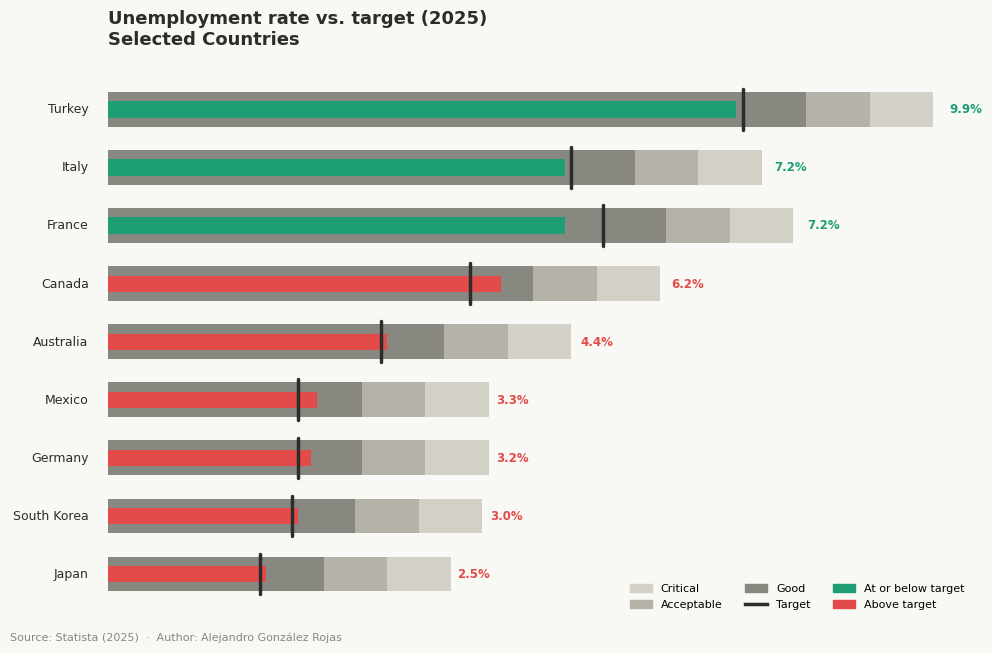

In [16]:
fig, ax = plt.subplots(figsize=(10, len(df) * 0.6 + 1))
fig.patch.set_facecolor("#F8F8F5")
ax.set_facecolor("#F8F8F5")
ax.axis("off")

df_sorted = df.sort_values("Unemployment Rate (%)", ascending=True).reset_index(drop=True)

for i, row in df_sorted.iterrows():
    y = i
    max_val = max(row["bad"], row["Unemployment Rate (%)"], row["Unemployment Target (%)"]) * 1.1

    ax.barh(y, row["bad"],  height=0.6,color="#D3D1C7", zorder=1)
    ax.barh(y, row["ok"],   height=0.6,color="#B4B2A9", zorder=1)
    ax.barh(y, row["good"], height=0.6,color="#888780", zorder=1)

    color = "#1D9E75" if row["Unemployment Rate (%)"] <= row["Unemployment Target (%)"] else "#E24B4A"
    
    ax.barh(y, row["Unemployment Rate (%)"], height=0.28, color=color, zorder=3)
    ax.plot([row["Unemployment Target (%)"],row["Unemployment Target (%)"]],[y - 0.35, y + 0.35], color="#2C2C2A", linewidth=2.5, zorder=4, solid_capstyle="round")

    ax.text(-0.3, y, row["Country"], ha="right",va="center", fontsize=9, color="#2C2C2A")
    ax.text(row["bad"] * 1.02, y, f"{row['Unemployment Rate (%)']}%", ha="left",va="center", fontsize=8.5, color=color, fontweight="bold")

ax.set_title("Unemployment rate vs. target (2025)\nSelected Countries",fontsize=13 , fontweight="bold", color="#2C2C2A",pad=14, loc="left")

legend = [
    mpatches.Patch(color="#D3D1C7", label="Critical"),
    mpatches.Patch(color="#B4B2A9", label="Acceptable"),
    mpatches.Patch(color="#888780", label="Good"),
    plt.Line2D([0], [0], color="#2C2C2A", linewidth=2.5, label="Target"),
    mpatches.Patch(color="#1D9E75", label="At or below target"),
    mpatches.Patch(color="#E24B4A", label="Above target"),
]
ax.legend(handles=legend, loc="lower right", fontsize=8,frameon=False, ncol=3)

fig.text(0.01, -0.01, "Source: Statista (2025)  ·  Author: Alejandro González Rojas",
         fontsize=8, color="#888780")
plt.tight_layout()
plt.show()

## Bullet Graph — Taxa d'Atur vs. Objectiu per País (2025)

**Font de dades:** 

Statista — Unemployment rate of G20 countries in 2025
https://www.statista.com/statistics/722965/g20-unemployment-rates/

Statista - Unemployment rate forecast in selected OECD countries from 2022 to 2025, by country
https://www.statista.com/statistics/1292535/unemployment-rate-forecasts-countries/


### Nom

**Bullet Graph** (Gràfic de Bala). També conegut com a bullet chart o grafic de termometre comparat. Es una variant compacta dels gràfics de mesura (gauge charts) disenyada especificament per a dashboards analítics on l'espai es limitat.

### Origen i autoria

El bullet graph va ser dissenyat per Stephen Few l'any 2005 com a resposta critica als velocimetres circulars (gauge charts) que dominaven els dashboards empresarials de l'epoca. Few el va formalitzar al seu article "Bullet Graph Design Specification" (2010) i al llibre Information Dashboard Design. L'objectiu era representar el rendiment d'una metrica respecte a un objectiu i uns rangs de qualitat en el mínim espai possible, sense sacrificar informació. Des de la seva publicació s'ha convertit en un estàndard de facto en visualització de KPIs.


### Avantatges i inconvenients

**Avantatges**
- Extremadament compacte
- Mostra simultàniament el valor real, l'objectiu i tres zones de qualitat en un sol element visual
- Ideal per a dashboards amb moltes metriques
- Permet comparar molts països o unitats d'un sol cop d'ull

**Inconvenients**
- Requereix llegenda i explicació prèvia, no és adequat per a metriques sense un objectiu de referència clar
- Les zones qualitatives (bo/acceptable/crític) poden ser subjectives i condicionar la interpretació
- No escala bé en dues dimensions simultànies

### Tipus de dades admeses

- Mètriques quantitatives
- Requereix un valor objectiu (target) de referència explícit
- Requereix rangs de qualitat definits, ja siguin absoluts, relatius al target o basats en la distribució del dataset
- No es adequat per a dades categòriques, sèries temporals, ni variables sense escala numerica


### Exemples i aplicacions habituals

- Taxes d'atur per país (com en aquest dataset): comparar el valor real de cada país contra el seu objectiu nacional
- KPIs de vendes: ingressos reals vs quota trimestral per equip o regió
- Energies renovables: percentatge actual vs objectiu climàtic
- Rendiment esportiu: mètrica d'un atleta vs marca personal i rècord de la competició

### Lectura del gràfic

- La barra fosca representa la taxa d'atur real del país l'any 2025
- La línia vertical marca l'objectiu (target) de cada país, proposada per cada pais d'accord al seu context economic
- Les tres zones de fons (de més fosc a més clar) indiquen els rangs de qualitat, bo (fins a target +1%), acceptable (fins a target +2%) i crític (fins a target +3%)
- Els països en verd han assolit o superat el seu objectiu i els països en vermell mse situen per sobre del target
- La ordenació ascendent per taxa real permet identificar rapidament els països amb millor i pitjor rendiment relatiu